# Regression in Python — Step-by-step Notebook
(Simple → Multiple → Polynomial → Regularization → Evaluation)

This notebook teaches regression progressively.

We will go in this order:
1) **Simple Linear Regression** (one feature)
2) **Multiple Linear Regression** (several features)
3) **Polynomial Regression** (curved patterns via feature expansion)
4) **Regularized Regression** (Ridge / Lasso)
5) **Train/Test Split + Metrics** (generalization)
6) **Cross-validation** (more reliable evaluation)
7) **Standardization** (critical for Ridge/Lasso)
8) **Residual diagnostics + assumption checks** (statistical sanity)

Notebook rules:
- We import **only what we need**, right before we need it.



In [1]:
# (Optional) Make results reproducible
import numpy as np
np.random.seed(42)

## Part 1 — Simple Linear Regression (one input feature)

### 1.1 The idea

We assume a relationship like:

$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

Where:
- $y$ is the target (what we want to predict)
- $x$ is the input feature
- $\beta_0$ is the **intercept** (baseline value of $y$ when $x=0$)
- $\beta_1$ is the **slope** (how much $y$ changes when $x$ increases by 1)
- $\varepsilon$ is the error/noise term (things not explained by the line)

### 1.2 What training means

Training (fitting) means: choose $\beta_0$ and $\beta_1$ that make predictions $\hat{y}$ as close as possible to the real $y$.

Prediction equation:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

The classic method is **Ordinary Least Squares (OLS)**: it chooses coefficients that minimize the sum of squared errors:

$$
\min_{\beta_0,\beta_1} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$


In [2]:
from sklearn.linear_model import LinearRegression

### 1.3 Create a tiny dataset
We’ll start with a perfectly linear dataset so you can see the mechanics clearly:

- $x$: 1,2,3,4
- $y$: 2,4,6,8


In [3]:
x = np.array([1, 2, 3, 4])
y = np.array([2, 4, 6, 8])

In [13]:
x.shape
z=x.reshape(2,2)
z.shape

(2, 2)

### 1.4 Convert `x` into a 2D matrix `X`

scikit-learn expects a **feature matrix** with shape `(n_samples, n_features)` because:
- **Consistency**: This format works for both single-feature and multi-feature datasets (the same API handles simple and multiple regression)
- **Matrix operations**: Under the hood, regression uses matrix algebra ($\mathbf{X}^\top \mathbf{X}$), which requires 2D arrays
- **Future-proofing**: If you later add more features, your code structure doesn't change—you just add columns

Here we have one feature, so `X` must be `(4, 1)`.

#### Matrix form of linear regression

In matrix notation, the linear model is:

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

Where:
- $\mathbf{y}$ is an $(n \times 1)$ vector of target values
- $\mathbf{X}$ is an $(n \times p)$ feature matrix ($n$ samples, $p$ features)

- For the "pure" feature matrix $\mathbf{X}$: shape is $(n \times p)$ where $p$ is the **number of features only** (no bias column)
- $\boldsymbol{\beta}$ is then $(p \times 1)$ containing $[\beta_1, \beta_2, \ldots, \beta_p]^\top$ (slopes only, no intercept)
- The intercept $\beta_0$ is handled separately by scikit-learn (stored in `model.intercept_`)

**In scikit-learn's `LinearRegression`:**
- You pass `X` with shape $(n \times p)$ (just the features)
- The model internally adds the intercept term (equivalent to augmenting with a column of ones)
- After fitting, you get `coef_` (the $p$ slopes) and `intercept_` (the $\beta_0$)

**If you manually add a column of ones** (like in statsmodels with `sm.add_constant(X)`):
- Then $\mathbf{X}_{\text{augmented}}$ has shape $(n \times (p+1))$
- $\boldsymbol{\beta}$ becomes $((p+1) \times 1)$ and includes $\beta_0$ as the first element
- $\boldsymbol{\beta}$ is a $(p \times 1)$ vector of coefficients $[\beta_1, \beta_2, \ldots, \beta_p]^\top$
- $\boldsymbol{\varepsilon}$ is an $(n \times 1)$ vector of errors

To include the intercept $\beta_0$, we typically add a column of ones to $\mathbf{X}$:

$$
\mathbf{X}_{\text{augmented}} = \begin{bmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1p} \\ 1 & x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{np} \end{bmatrix}
$$

Then $\boldsymbol{\beta} = [\beta_0, \beta_1, \ldots, \beta_p]^\top$.

#### OLS solution (normal equations)

The coefficient vector that minimizes $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$ is:

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

**Dimension check:**
- $\mathbf{X}$: $(n \times p)$
- $\mathbf{X}^\top$: $(p \times n)$
- $\mathbf{X}^\top \mathbf{X}$: $(p \times p)$
- $(\mathbf{X}^\top \mathbf{X})^{-1}$: $(p \times p)$
- $\mathbf{X}^\top \mathbf{y}$: $(p \times 1)$
- $\hat{\boldsymbol{\beta}}$: $(p \times 1)$ ✓

This is why scikit-learn **requires** `X` to be 2D: the formula only works when `X` is a proper matrix.


In [15]:
X = x.reshape(-1, 1)
print('X shape:', X.shape)
print('y shape:', y.shape)
X

X shape: (4, 1)
y shape: (4,)


array([[1],
       [2],
       [3],
       [4]])

The reshape(-1, 1) operation converts a 1D array into a 2D column vector. reshape(-1, 1) is NumPy's standard way to convert any 1D array into a proper column matrix for scikit-learn.


### 1.5 Define and fit the model

We:
1) Create the model object (empty)
2) Call `.fit(X, y)` to estimate $\beta_0$ and $\beta_1$


In [16]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 1.6 Inspect coefficients and make a prediction

After fitting, scikit-learn stores:
- `intercept_` = $\beta_0$
- `coef_` = $\beta_1$ (or a vector of coefficients if multiple features)


In [17]:
beta0 = model.intercept_
beta1 = model.coef_[0]

print('beta0 (intercept) =', beta0)
print('beta1 (slope)     =', beta1)

X_new = np.array([[5], [6]])
print('Predictions for x=5,6:', model.predict(X_new))

beta0 (intercept) = 0.0
beta1 (slope)     = 2.0
Predictions for x=5,6: [10. 12.]


## Part 2 — Multiple Linear Regression (more than one feature)

Now we model:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon
$$

Interpretation is key:
- $\beta_1$ is the effect of $x_1$ **holding $x_2$ constant**
- $\beta_2$ is the effect of $x_2$ **holding $x_1$ constant**


### 2.1 Create a dataset with two features

`X_multi` has 2 columns, so its shape is `(n_samples, 2)`.


In [18]:
X_multi = np.array([
    [1, 10],
    [2, 20],
    [3, 30],
    [4, 40]
])
y_multi = np.array([5, 9, 13, 17])
print('X_multi shape:', X_multi.shape)

X_multi shape: (4, 2)


### 2.2 Fit and inspect coefficients


In [20]:
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print('Intercept:', multi_model.intercept_)
print('Coefficients [beta1, beta2]:', multi_model.coef_)

X_new_multi = np.array([[5, 50]])
print('Predictions:', multi_model.predict(X_new_multi))

Intercept: 0.9999999999999964
Coefficients [beta1, beta2]: [0.03960396 0.3960396 ]
Predictions: [21.]


## Part 3 — Polynomial Regression (curves via feature expansion)

Sometimes the mean relationship is curved. Example quadratic:

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \varepsilon
$$

We can still use linear regression if we expand features from `[x]` to `[x, x^2]`.
That is **feature expansion**.


In [21]:
from sklearn.preprocessing import PolynomialFeatures

### 3.1 Curved dataset


In [22]:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([1, 2, 5, 10, 17, 26])  # approx y = x^2 + 1
X = x.reshape(-1, 1)

### 3.2 Expand to degree-2 features and fit


In [23]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print('Original X shape:', X.shape)
print('Expanded X_poly shape:', X_poly.shape)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print('Intercept:', poly_model.intercept_)
print('Coefficients (for x and x^2):', poly_model.coef_)

X_new = np.array([[6], [7]])
print('Predictions:', poly_model.predict(poly.transform(X_new)))

Original X shape: (6, 1)
Expanded X_poly shape: (6, 2)
Intercept: 1.0000000000000018
Coefficients (for x and x^2): [-1.30327354e-15  1.00000000e+00]
Predictions: [37. 50.]


## Part 4 — Regularized Regression (Ridge and Lasso)

### 4.1 Why regularize?

With many features (or noisy data), plain OLS can overfit.
Regularization adds a penalty that discourages large coefficients.

**Ridge (L2)** minimizes:

$$
\sum (y-\hat{y})^2 + \alpha \sum \beta_j^2
$$

**Lasso (L1)** minimizes:

$$
\sum (y-\hat{y})^2 + \alpha \sum |\beta_j|
$$

Practical behavior:
- Ridge shrinks coefficients smoothly
- Lasso can shrink some coefficients to exactly 0


In [24]:
from sklearn.linear_model import Ridge, Lasso

### 4.2 Fit Ridge and Lasso (toy example)


In [25]:
X = np.array([
    [1, 10],
    [2, 20],
    [3, 30],
    [4, 40],
    [5, 50]
])
y = np.array([6, 11, 16, 21, 26])

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X, y)
lasso.fit(X, y)

print('Ridge intercept:', ridge.intercept_)
print('Ridge coef:     ', ridge.coef_)

print('Lasso intercept:', lasso.intercept_)
print('Lasso coef:     ', lasso.coef_)

Ridge intercept: 1.0148367952522275
Ridge coef:      [0.04945598 0.49455984]
Lasso intercept: 1.0150000000000006
Lasso coef:      [0.     0.4995]


## Part 5 — Train/Test Split + Metrics (generalization)

Up to now, we mostly trained and predicted on the same data.
That’s fine for learning syntax, but it’s **not** how you judge a model.

### 5.1 Why split?

We want to estimate how the model performs on **new, unseen data**.
So we split the dataset into:
- **Train set**: used to learn coefficients
- **Test set**: used only for evaluation

### 5.2 A more realistic dataset

We’ll generate noisy data from a known true model:

$$
y = 3 + 2x + \varepsilon,\quad \varepsilon \sim \mathcal{N}(0, 2^2)
$$

So the true intercept is 3 and true slope is 2.


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate data
n = 200
x = np.random.uniform(0, 10, size=n)
eps = np.random.normal(0, 2.0, size=n)
y = 3 + 2*x + eps

X = x.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Learned intercept:', lin.intercept_)
print('Learned slope:    ', lin.coef_[0])

print('MAE :', mae)
print('MSE :', mse)
print('RMSE:', rmse)
print('R^2 :', r2)

Learned intercept: 2.6052828797352063
Learned slope:     2.1113368723673167
MAE : 1.5247539185198287
MSE : 3.4351153310531646
RMSE: 1.85340641281214
R^2 : 0.907768286632193


### Metric intuition (quick and useful)

- **MAE**: average absolute error (easy to interpret; same units as y)
- **RMSE**: like MAE but punishes big mistakes more
- **R²**: fraction of variance explained (1 is perfect, 0 is “predict the mean”, negative is worse than mean)



**R² (R-squared)** = fraction of variance in the target explained by the model.

**Formula:**

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

Where:
- $\text{SS}_{\text{res}} = \sum (y_i - \hat{y}_i)^2$ = sum of squared residuals (errors you made)
- $\text{SS}_{\text{tot}} = \sum (y_i - \bar{y})^2$ = total variance in y (if you just predicted the mean)

**Intuition:**

R² measures "how much better is my model than just guessing the mean?"

**Interpretation:**

| R² Value | Meaning |
|----------|---------|
| **1.0** | Perfect fit—model explains all variance |
| **0.9** | Excellent—explains 90% of variance |
| **0.5** | Moderate—explains 50% of variance |
| **0.0** | Terrible—model is as good as predicting the mean |
| **Negative** | Worse than predicting the mean (very bad) |

**Example:**

Say you're predicting house prices and:
- Mean price = $300k
- Your model's prediction error = $20k on average
- Variance of actual prices = $100k

Then R² ≈ 0.96 → model explains 96% of the price variation.

**In your notebook:**

```python
r2 = r2_score(y_test, y_pred)
print('R^2:', r2)
```

Higher R² on test set = better generalization. If R² on test is much lower than on train = overfitting.

## Part 6 — Cross-validation (more reliable evaluation)

A single train/test split can be unlucky.
Cross-validation repeats the evaluation across multiple splits.

### 6.1 K-Fold CV idea

In **K-fold** CV:
- Split data into K folds
- Train on K-1 folds
- Test on the remaining fold
- Repeat K times and average results

This gives a more stable estimate of performance.


In [29]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2')

print('R^2 scores across folds:', scores)
print('Mean R^2:', scores.mean())
print('Std  R^2:', scores.std())

R^2 scores across folds: [0.90591024 0.85663188 0.89120335 0.83778834 0.89713776]
Mean R^2: 0.8777343140023952
Std  R^2: 0.026049126875889412


### Note on scoring

We used `scoring='r2'`.
You can also use negative error metrics like:
- `neg_mean_squared_error`
- `neg_mean_absolute_error`

They’re negative because scikit-learn assumes “higher is better” for scores.


In [30]:
mse_scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)

print('RMSE per fold:', rmse_scores)
print('Mean RMSE:', rmse_scores.mean())
print('Std  RMSE:', rmse_scores.std())

RMSE per fold: [1.89952748 2.05841591 2.24672302 2.1932554  2.18892138]
Mean RMSE: 2.117368639974536
Std  RMSE: 0.12533263551906473


## Part 7 — Standardization (critical for Ridge/Lasso)

### 7.1 Why scale features?

Regularization penalties depend on coefficient size.
If features are on very different scales (e.g., dollars vs kilometers), coefficients become incomparable.

**Standardization** rescales each feature to mean 0 and standard deviation 1:

$$
z = \frac{x - \mu}{\sigma}
$$

This is especially important for **Ridge/Lasso**.

### 7.2 The safe way: Pipeline

Use a pipeline so scaling is learned on training folds only (prevents leakage).


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a multi-feature dataset with different scales
n = 400
x1 = np.random.uniform(0, 10, size=n)         # small scale
x2 = np.random.uniform(0, 10000, size=n)      # huge scale
eps = np.random.normal(0, 5.0, size=n)
# True model: y = 10 + 2*x1 - 0.001*x2 + noise
y_big = 10 + 2*x1 - 0.001*x2 + eps

X_big = np.column_stack([x1, x2])

# Ridge without scaling
ridge_raw = Ridge(alpha=10.0)
raw_scores = cross_val_score(ridge_raw, X_big, y_big, cv=5, scoring='r2')

# Ridge with scaling
ridge_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0))
])
scaled_scores = cross_val_score(ridge_scaled, X_big, y_big, cv=5, scoring='r2')

print('Ridge R^2 without scaling (mean):', raw_scores.mean())
print('Ridge R^2 with scaling    (mean):', scaled_scores.mean())

Ridge R^2 without scaling (mean): 0.6516545297088138
Ridge R^2 with scaling    (mean): 0.6512210690443203


### What you should take away

Even when performance looks similar, scaling changes the meaning of the penalty and the stability of optimization.
In real datasets with many features, scaling can be the difference between a sane model and chaos.


## Part 8 — Residual diagnostics + assumption checks

Regression isn’t just `fit()`.
A professional workflow checks whether model assumptions are “approximately reasonable.”

Recall the model:

$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

Key assumptions (classical OLS):
1) Linearity (mean of y is linear in x)
2) Errors have mean 0
3) Constant variance of errors (homoskedasticity)
4) Errors are independent
5) (For inference) errors are approximately normal

We’ll do *practical* checks using plots and a couple of standard tests.


In [32]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

### 8.1 Fit a model (again) and compute residuals

Residuals are:

$$
e_i = y_i - \hat{y}_i
$$

They are the part of y not explained by the model.


In [33]:
# Reuse the noisy simple dataset from Part 5
lin = LinearRegression()
lin.fit(X_train, y_train)
y_hat_train = lin.predict(X_train)
resid_train = y_train - y_hat_train

print('Residual mean (should be ~0):', resid_train.mean())

Residual mean (should be ~0): -1.3737159558028603e-15


### 8.2 Residuals vs fitted values (linearity + heteroskedasticity)

**What to look for**:
- Random cloud around 0: good sign
- Curved pattern: model missing nonlinearity
- Funnel shape (wider as fitted increases): heteroskedasticity


Updated todo list

**Heteroskedasticity** = non-constant variance in residuals (errors don't have the same spread across all predictions).

**In regression**, OLS assumes **homoskedasticity**: the errors have the same variance everywhere. Heteroskedasticity violates this.

**Visual example:**

Homoskedastic (good):
```
      ●  ●           ●  ●
    ●        ●     ●        ●
  ●            ●●             ●
────────────────────────────────
```
Random cloud with consistent width → errors have equal spread.

Heteroskedastic (bad):
```
      ●
        ●  ●
          ●     ●
            ●        ●
          ●             ●
────────────────────────────────
```
"Funnel shape" → errors get wider as fitted values increase.

**Why it matters:**

- **OLS coefficients** are still unbiased, but **confidence intervals and p-values are wrong**
- You might think your model is more precise than it actually is
- Example: predicting house prices—errors are small for cheap houses but huge for expensive ones

**How to detect it:**

In your notebook, the Breusch–Pagan test (`het_breuschpagan`) checks for heteroskedasticity. Small p-value = heteroskedasticity present.

**How to fix it:**

- Use robust standard errors (statsmodels handles this)
- Transform the target (e.g., log-transform y)
- Use weighted least squares
- Try a different model

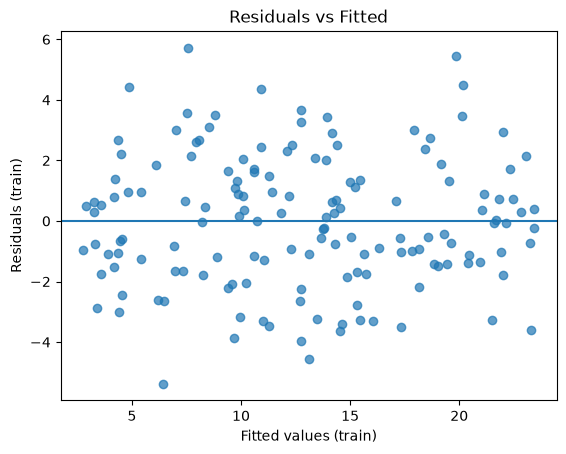

In [35]:
plt.figure()
plt.scatter(y_hat_train, resid_train, alpha=0.7)
plt.axhline(0)
plt.xlabel('Fitted values (train)')
plt.ylabel('Residuals (train)')
plt.title('Residuals vs Fitted')
plt.show()

### 8.3 Histogram of residuals (shape check)

This is a rough normality check.
Normal-ish is good for t-tests and confidence intervals.


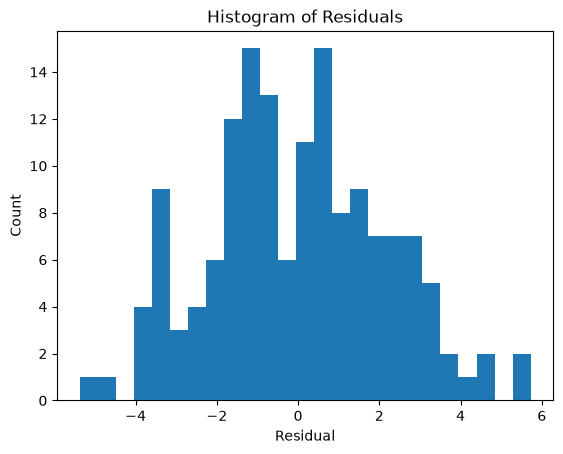

In [36]:
plt.figure()
plt.hist(resid_train, bins=25)
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals')
plt.show()

### 8.4 Q–Q plot (normality check)

If residuals are normal, points fall roughly on the diagonal line.
Big deviations in the tails = heavy tails / outliers.


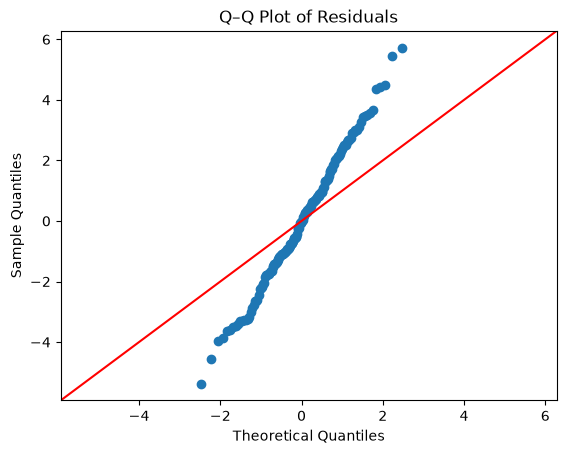

In [37]:
sm.qqplot(resid_train, line='45')
plt.title('Q–Q Plot of Residuals')
plt.show()

### 8.5 Breusch–Pagan test (heteroskedasticity)

This test checks whether residual variance depends on the predictors.

Null hypothesis: homoskedasticity (constant variance).

If p-value is small (e.g., < 0.05), that suggests heteroskedasticity.


In [ ]:
# For BP test we use statsmodels OLS with an explicit intercept
X_sm = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_sm).fit()

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(ols.resid, ols.model.exog)

print('Breusch–Pagan p-value:', bp_pvalue)
print('F-test p-value:', f_pvalue)

Breusch–Pagan p-value: 0.5625890764154379
F-test p-value: 0.5656444581080282


### 8.6 Quick note on “what if assumptions fail?”

- Nonlinearity → try polynomial features, splines, or a different model
- Heteroskedasticity → use robust standard errors (statsmodels) or transform y
- Outliers/heavy tails → consider robust regression or investigate data quality
- Autocorrelation (time series) → use time-series models or add lag features



# End

Covered above:
- A clean syntax progression (simple → multi → poly → ridge/lasso)
- Proper evaluation (train/test + metrics)
- More reliable evaluation (cross-validation)
- Correct preprocessing for regularization (standardization via pipeline)
- Residual diagnostics + a classic heteroskedasticity test
